## Objective
The goal of this notebook is to transform the raw JobVision dataset into a
clean, consistent, and analysis-ready dataset.
This stage focuses on improving data quality while preserving all information
required for downstream feature engineering and the recommendation engine.
The cleaned dataset generated here will serve as the foundation for the
remaining stages of the project.

In [67]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from bs4 import BeautifulSoup
import re
from collections import Counter


pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "jobs_clean.csv"
DATA_PATH

WindowsPath('d:/Iran_Job_Market/data/processed/jobs_clean.csv')

In [12]:
df = pd.read_csv(DATA_PATH)
df.head()

,keyword,job_id,title,company,province,city,salary_visible,experience_years,description,work_type,seniority,category,company_size,industries,benefits,salary_title,salary_min,salary_max,gender,required_age_min,required_age_max,military,work_days,business_trip,software,software_levels,first_activation,activation,expire,application_count,internship,remote,urgent
0,python,1396130,برنامه نویس Python,بارکس,تهران,تهران,False,5,ما برای توسعه ERP شرکت بر پایه Odoo به دنبال یک توسعه‌دهنده مسلط هستیم که توانایی توسعه ماژول‌ها...,Full Time,Senior Specialist,"IT - Software Development (Web,Moblie,…)",11 - 50 employees,Transportation / Logistics,"Loan,Bonus,Snacks\r\n,Occasional packages and gifts",NaN,NaN,NaN,Men / Women,NaN,NaN,False,شنبه تا چهارشنبه 8ت5پنج شنبه از 8صبح الی2,NaN,"Python,Oracle Database,GIT","Advanced,Basic,Basic",2026-05-20 15:30:13,2026-05-20 15:30:13,2026-07-19 15:30:13,495.0,False,False,True
1,python,1401623,Senior Backend Engineer(Python/FastAPI)- Shoraka,بیمه بازار,تهران,تهران,False,3,We are looking for a Senior Backend Engineer to join our team and contribute to the development ...,Full Time,Senior Specialist,"IT - Software Development (Web,Moblie,…)",501 - 1000 employees,"Internet Provider / E-commerce / Online Services,Insurance",NaN,NaN,NaN,NaN,Men / Women,NaN,NaN,False,Saturday to Wednesday,NaN,"Python,PostgreSql,Prometheus,Gerafana,Docker,Redis,Kubernetes","Advanced,Intermediate,Intermediate,Intermediate,Intermediate,Intermediate,Intermediate",NaN,NaN,NaN,805.0,False,True,True
2,python,1436012,برنامه نویس Python,ارتباطات فرهنگ آزما,تهران,تهران,False,2,ما در تیم تحقیق و توسعه فرهنگ آزما به دنبال یک توسعه دهنده Backend هستیم تا به تیم ما بپیوندد و ...,Full Time,Specialist,"IT - Software Development (Web,Moblie,…)",11 - 50 employees,"IT / Software / Hardware,Internet Provider / E-commerce / Online Services",Occasional packages and gifts,NaN,NaN,NaN,Men / Women,22.0,40.0,False,شنبه تا چهارشنبه 8:30 الی 18,NaN,"Python,Django,GIT,MySql,PostgreSql,Redis,Linux,Rest API,Unit Testing","Advanced,Advanced,Advanced,Intermediate,Intermediate,Basic,Intermediate,Intermediate,Basic",NaN,NaN,NaN,354.0,False,False,False
3,python,1390562,برنامه نویس بک‌اند (Python/Django),شرکت بیمۀ زندگی باران,تهران,تهران,False,3,اگر توسعه‌دهنده‌ای هستید که چالش‌های فنی شما را هیجان‌زده می‌کند و به ساخت راهکارهای خلاقانه علا...,Full Time,Specialist,"IT - Software Development (Web,Moblie,…)",11 - 50 employees,Insurance,"Loan,Bonus,Health insurance\r\n,Flexible working hours\r\n,Learning stipends\r\n,Purchasing coup...",NaN,NaN,NaN,Men / Women,23.0,33.0,True,شنبه تا سه شنبه از 08:00 الی 17:00 و چهارشنبه از ساعت 08:00 الی ساعت 16:00 (با یک ساعت شناوری صبح),NaN,"Python,Django,GIT,Linux","Intermediate,Intermediate,Basic,Basic",NaN,NaN,NaN,882.0,False,False,True
4,python,1429358,برنامه نویس Python,شرکت پیشگامان توسعه ارتباطات,تهران,تهران,False,2,نکات فنی: تسلط بر Django آشنایی با DRF آشنایی با Design Patterns آشنایی با Git داشتن آشنایی و سا...,Full Time,Specialist,"IT - Software Development (Web,Moblie,…)",201 - 500 employees,"IT / Software / Hardware,Internet Provider / E-commerce / Online Services","Health insurance\r\n,Occasional packages and gifts",NaN,NaN,NaN,Men / Women,19.0,40.0,True,شنبه تا سه‌شنبه 8 تا 17، چهارشنبه 8 تا 16,NaN,"Linux,Django,GIT,Python","Intermediate,Advanced,Intermediate,Intermediate",2026-06-22 15:16:03,2026-06-22 15:16:03,2026-08-21 15:16:03,587.0,False,False,False


In [14]:
print(f"Dataset Shape: {df.shape}")
df.info()

Dataset Shape: (12037, 33)
<class 'pandas.DataFrame'>
RangeIndex: 12037 entries, 0 to 12036
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   keyword            12037 non-null  str    
 1   job_id             12037 non-null  int64  
 2   title              12037 non-null  str    
 3   company            12037 non-null  str    
 4   province           12014 non-null  str    
 5   city               12037 non-null  str    
 6   salary_visible     12037 non-null  bool   
 7   experience_years   12037 non-null  int64  
 8   description        12037 non-null  str    
 9   work_type          12037 non-null  str    
 10  seniority          12037 non-null  str    
 11  category           12037 non-null  str    
 12  company_size       12037 non-null  str    
 13  industries         12037 non-null  str    
 14  benefits           9732 non-null   str    
 15  salary_title       4083 non-null   str    
 16  salary

In [15]:
df.describe()

,job_id,experience_years,salary_min,salary_max,required_age_min,required_age_max,application_count
count,1.203700e+04,12037.000000,4083.000000,4083.000000,7984.000000,8085.000000,11614.000000
mean,1.418634e+06,2.912437,37.957384,52.469753,24.888277,38.492888,275.639487
std,4.461337e+04,2.030666,21.876399,30.006634,4.310572,5.390685,315.040833
min,2.336850e+05,0.000000,3.000000,4.000000,18.000000,20.000000,11.000000
25%,1.408943e+06,2.000000,25.000000,35.000000,22.000000,35.000000,67.000000
50%,1.424504e+06,3.000000,30.000000,45.000000,25.000000,40.000000,153.000000
75%,1.438436e+06,4.000000,45.000000,60.000000,27.000000,40.000000,373.750000
max,1.452239e+06,20.000000,300.000000,400.000000,50.000000,50.000000,4660.000000


## Missing Values Analysis
Missing values are analyzed to understand the completeness of each feature.
Not every missing value represents a data quality issue. Some fields are
optional and the absence of information may have a business meaning.
The decision to remove, fill, or preserve missing values will be made after
understanding the role of each feature in the recommendation system.

In [18]:
def missing_values_report(df: pd.DataFrame) -> pd.DataFrame:
    missing_count = df.isna().sum()
    missing_percentage = (missing_count / len(df) * 100)
    report = pd.DataFrame(
        {
            "missing_count": missing_count,
            "missing_percentage": missing_percentage
        }
    )
    report = (report.sort_values(by="missing_percentage", ascending=False))
    return report

In [19]:
missing_report = missing_values_report(df)
missing_report

,missing_count,missing_percentage
business_trip,11015,91.509512
expire,8373,69.560522
first_activation,8373,69.560522
activation,8373,69.560522
salary_min,7954,66.079588
salary_max,7954,66.079588
salary_title,7954,66.079588
required_age_min,4053,33.671181
required_age_max,3952,32.832101
software_levels,3507,29.135167


In [20]:
missing_report[missing_report["missing_count"] > 0]

,missing_count,missing_percentage
business_trip,11015,91.509512
expire,8373,69.560522
first_activation,8373,69.560522
activation,8373,69.560522
salary_min,7954,66.079588
salary_max,7954,66.079588
salary_title,7954,66.079588
required_age_min,4053,33.671181
required_age_max,3952,32.832101
software_levels,3507,29.135167


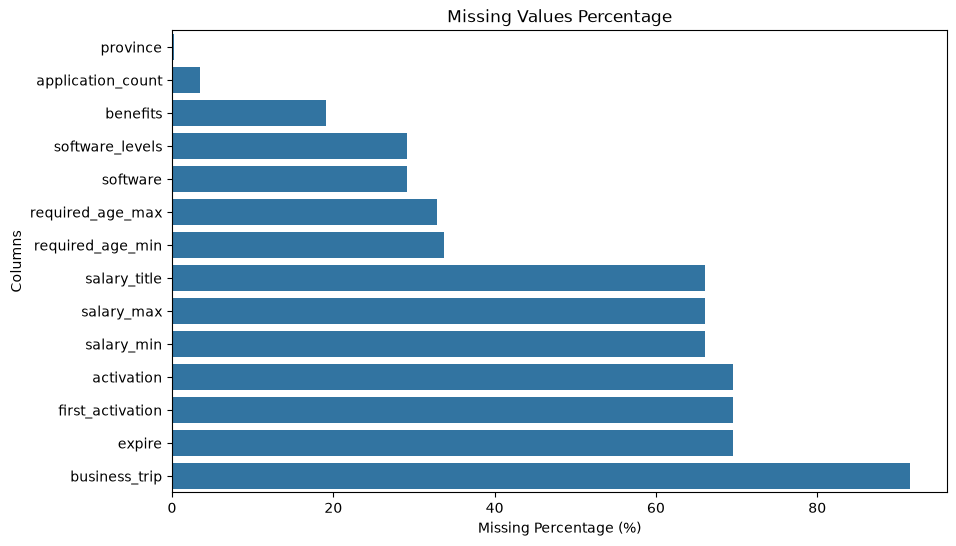

In [27]:
missing_data = (
    missing_report[missing_report["missing_count"] > 0]
    .sort_values("missing_percentage", ascending=True)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=missing_data,
    x="missing_percentage",
    y=missing_data.index
)

plt.xlabel("Missing Percentage (%)")
plt.ylabel("Columns")
plt.title("Missing Values Percentage")

plt.show()

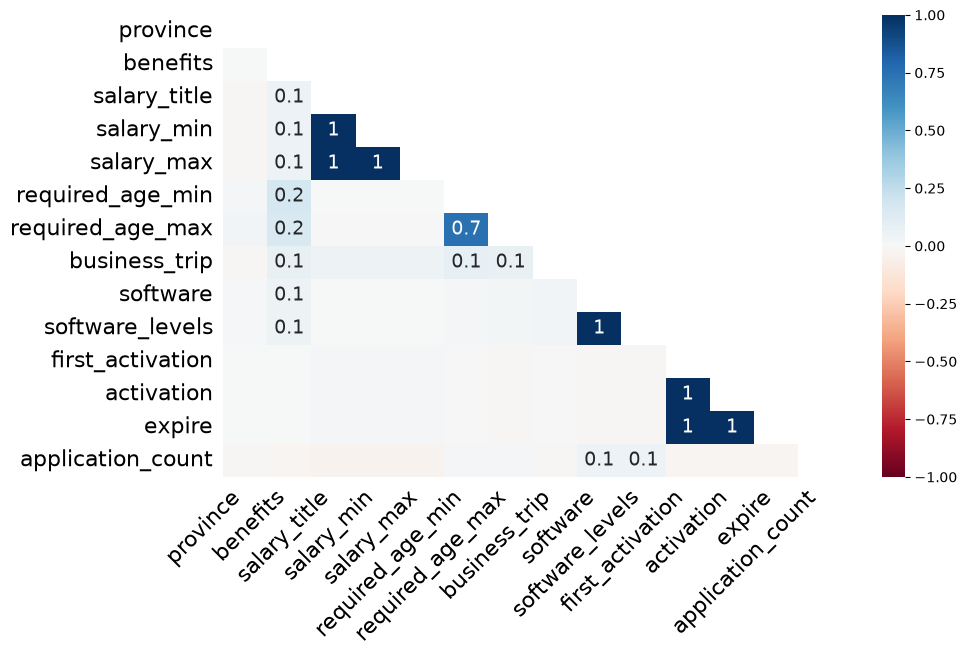

In [ ]:
msno.heatmap(df, figsize=(10,6))
plt.show()

## Data Quality Assessment

Before modifying the dataset, we inspect its quality to identify missing values,
duplicate records, inconsistent formats, invalid values, and potential issues
that may affect downstream analysis.

In [34]:
job_id_duplicates = df["job_id"].duplicated().sum()
print(f"Duplicate job_id count: {job_id_duplicates}")

full_duplicates = df.duplicated().sum()
print(f"Fully duplicated rows: {full_duplicates}")

duplicate_check_columns = ["title", "company", "city", "description"]
similar_duplicates = df.duplicated(subset=duplicate_check_columns, keep=False)
print(f"Potential similar duplicates: {similar_duplicates.sum()}")

Duplicate job_id count: 0
Fully duplicated rows: 0
Potential similar duplicates: 8


## Date Columns Conversion
Date columns are currently stored as strings.
They need to be converted into datetime format to enable date-based analysis
and future feature engineering.

In [39]:
date_columns = ["first_activation", "activation", "expire"]
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df[date_columns].isna().sum()

first_activation    8373
activation          8373
expire              8373
dtype: int64

## Numeric Values Validation
Numeric features are checked for invalid or impossible values before further
processing.
The goal is to identify data quality issues without modifying the original
values unnecessarily.

In [40]:
numeric_columns = ["experience_years", "salary_min", "salary_max", "required_age_min", "required_age_max", "application_count"]
df[numeric_columns].describe()

,experience_years,salary_min,salary_max,required_age_min,required_age_max,application_count
count,12037.000000,4083.000000,4083.000000,7984.000000,8085.000000,11614.000000
mean,2.912437,37.957384,52.469753,24.888277,38.492888,275.639487
std,2.030666,21.876399,30.006634,4.310572,5.390685,315.040833
min,0.000000,3.000000,4.000000,18.000000,20.000000,11.000000
25%,2.000000,25.000000,35.000000,22.000000,35.000000,67.000000
50%,3.000000,30.000000,45.000000,25.000000,40.000000,153.000000
75%,4.000000,45.000000,60.000000,27.000000,40.000000,373.750000
max,20.000000,300.000000,400.000000,50.000000,50.000000,4660.000000


In [43]:
salary_issue = df[(df["salary_min"] > df["salary_max"])]
print(f"Salary inconsistency count: {len(salary_issue)}")

age_issue = df[(df["required_age_min"] > df["required_age_max"])]
print(f"Age inconsistency count: {len(age_issue)}")

Salary inconsistency count: 0
Age inconsistency count: 0


## Boolean Columns Validation
Boolean features are checked to ensure they contain only valid True/False
values and do not include unexpected values or missing records.

In [44]:
boolean_columns = ["salary_visible", "military", "internship", "remote", "urgent"]
df[boolean_columns].dtypes

salary_visible    bool
military          bool
internship        bool
remote            bool
urgent            bool
dtype: object

In [45]:
for col in boolean_columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


salary_visible
salary_visible
False    7954
True     4083
Name: count, dtype: int64

military
military
False    6952
True     5085
Name: count, dtype: int64

internship
internship
False    11762
True       275
Name: count, dtype: int64

remote
remote
False    11331
True       706
Name: count, dtype: int64

urgent
urgent
False    6079
True     5958
Name: count, dtype: int64


## Text Columns Profiling

Text columns contain important information for the recommendation system.

Before applying any text cleaning or normalization, the current quality of text
features is inspected to identify empty values, inconsistent formatting, and
potential preprocessing requirements.

In [49]:
text_columns = [
    "keyword",
    "title",
    "company",
    "province",
    "city",
    "description",
    "work_type",
    "seniority",
    "category",
    "company_size",
    "industries",
    "benefits",
    "salary_title",
    "gender",
    "work_days",
    "software",
    "software_levels"
]

In [50]:
empty_string_report = {}

for col in text_columns:
    empty_count = (df[col].astype(str).str.strip().eq("").sum())
    empty_string_report[col] = empty_count


pd.DataFrame(empty_string_report.items(), columns=["column", "empty_string_count"]).sort_values(by="empty_string_count", ascending=False)

,column,empty_string_count
0,keyword,0
1,title,0
2,company,0
3,province,0
4,city,0
5,description,0
6,work_type,0
7,seniority,0
8,category,0
9,company_size,0


In [51]:
whitespace_report = {}

for col in text_columns:
    count = (df[col].dropna().astype(str).apply(lambda x: x != x.strip()).sum())
    whitespace_report[col] = count
pd.DataFrame(
    whitespace_report.items(),
    columns=["column", "leading_trailing_space_count"]
).sort_values(
    by="leading_trailing_space_count",
    ascending=False
)

,column,leading_trailing_space_count
0,keyword,0
1,title,0
2,company,0
3,province,0
4,city,0
5,description,0
6,work_type,0
7,seniority,0
8,category,0
9,company_size,0


In [ ]:
unique_report = (df[text_columns].nunique().sort_values(ascending=False).to_frame("unique_count"))
unique_report

,unique_count
description,11802
title,6586
work_days,6077
company,5886
software,3942
benefits,2794
industries,771
software_levels,676
salary_title,366
category,309


## Description HTML Cleaning
Job descriptions are collected from web pages and contain HTML formatting.
HTML tags and unnecessary formatting characters are removed while preserving
the original text content for future NLP-based feature extraction.

In [53]:
df["description"].iloc[0]

'ما برای توسعه ERP شرکت بر پایه Odoo به دنبال یک توسعه\u200cدهنده مسلط هستیم که توانایی توسعه ماژول\u200cهای تمیز، قابل توسعه و قابل نگهداری را داشته باشد. 🎯 مسئولیت\u200cها توسعه و سفارشی\u200cسازی ماژول\u200cهای Odoo طراحی و پیاده\u200cسازی منطق\u200cهای بیزینسی با Python کار با Odoo ORM (models, fields, recordsets) توسعه و ویرایش Viewها با XML (form, list, kanban) بهینه\u200cسازی performance و کوئری\u200cها در PostgreSQL همکاری نزدیک با تیم محصول برای پیاده\u200cسازی فیچرها ✅ شرایط احراز (Must-have) تسلط به Python تجربه عملی کار با Odoo (حداقل 1 پروژه واقعی) آشنایی با Odoo ORM و ساختار ماژول\u200cها تسلط به XML برای طراحی View آشنایی با PostgreSQL درک مفاهیم object-oriented و design اصولی درک اصول طراحی نرم\u200cافزار (SOLID، Clean Code) آشنایی با مفاهیم پیشرفته پایتون (decorators، generators، context managers) آشنایی با Design Patternهای رایج (Factory، Repository، Service Layer) توانایی تحلیل و بهینه\u200cسازی performance در سطح کد و دیتابیس آشنایی با Git و فرآیندهای توسعه تیمی (co

In [61]:
def clean_html_text(text):
    """
    Remove HTML tags and normalize text formatting.
    Parameters
    ----------
    text : str
        Raw description text.
    Returns
    -------
    str
        Cleaned plain text.
    """

    if pd.isna(text):
        return text

    # Remove HTML tags
    text = BeautifulSoup(
        text,
        "html.parser"
    ).get_text(" ")

    # Remove zero-width characters
    text = re.sub(r"[\u200b\u200c\u200d\ufeff]", " ", text)

    # Remove excessive whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [62]:
df["description"] = df["description"].apply(clean_html_text)

In [63]:
df["description"].iloc[0]

'ما برای توسعه ERP شرکت بر پایه Odoo به دنبال یک توسعهدهنده مسلط هستیم که توانایی توسعه ماژولهای تمیز، قابل توسعه و قابل نگهداری را داشته باشد. 🎯 مسئولیتها توسعه و سفارشیسازی ماژولهای Odoo طراحی و پیادهسازی منطقهای بیزینسی با Python کار با Odoo ORM (models, fields, recordsets) توسعه و ویرایش Viewها با XML (form, list, kanban) بهینهسازی performance و کوئریها در PostgreSQL همکاری نزدیک با تیم محصول برای پیادهسازی فیچرها ✅ شرایط احراز (Must-have) تسلط به Python تجربه عملی کار با Odoo (حداقل 1 پروژه واقعی) آشنایی با Odoo ORM و ساختار ماژولها تسلط به XML برای طراحی View آشنایی با PostgreSQL درک مفاهیم object-oriented و design اصولی درک اصول طراحی نرمافزار (SOLID، Clean Code) آشنایی با مفاهیم پیشرفته پایتون (decorators، generators، context managers) آشنایی با Design Patternهای رایج (Factory، Repository، Service Layer) توانایی تحلیل و بهینهسازی performance در سطح کد و دیتابیس آشنایی با Git و فرآیندهای توسعه تیمی (code review، branching) ➕ مزیت محسوب میشود تجربه کار با Odoo Owl / JavaScript آش

## Software Features Cleaning
Software and software level features represent technical skills required by
each job posting.
These columns will be transformed into structured lists to enable future skill
matching and recommendation modeling.

In [64]:
df[["software", "software_levels"]].dropna().sample(10, random_state=42)

,software,software_levels
2947,"Microsoft Word,Microsoft Excel","Intermediate,Intermediate"
11156,"Adobe Photoshop,Adobe Premiere","Intermediate,Basic"
8641,"دیدار,Microsoft Excel,Microsoft Word","Advanced,Intermediate,Intermediate"
7517,"Microsoft Word,Microsoft Excel,Microsoft Access,Microsoft Powerpoint,Microsoft Visio,Microsoft O...","Advanced,Advanced,Intermediate,Intermediate,Basic,Advanced"
8252,"Adobe Photoshop,Adobe Illustrator,Adobe Indesign,After Effects","Advanced,Advanced,Intermediate,Basic"
7896,"After Effects,Adobe Premiere,Adobe Photoshop,Adobe Illustrator,Davinci Resolve","Advanced,Advanced,Intermediate,Intermediate,Intermediate"
2726,سپیدار,Advanced
1685,"Microsoft Excel,Primavera,Microsoft Word","Basic,Intermediate,Intermediate"
10161,"Adobe Photoshop,Adobe Premiere,Wordpress","Basic,Basic,Basic"
6703,Microsoft Excel,Intermediate


In [65]:
software_counts = (df["software"].dropna().apply(lambda x: len(x.split(","))))
software_counts.describe()

count    8530.000000
mean        3.268581
std         2.018024
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        20.000000
Name: software, dtype: float64

In [68]:
software_counter = Counter()

for skills in df["software"].dropna():
    for skill in skills.split(","):
        software_counter[skill.strip()] += 1

software_counter.most_common(30)

[('Microsoft Excel', 4252),
 ('Microsoft Word', 2910),
 ('Adobe Photoshop', 868),
 ('Microsoft Powerpoint', 742),
 ('GIT', 665),
 ('Sql Server', 664),
 ('Python', 523),
 ('PowerBI', 518),
 ('Linux', 503),
 ('Adobe Premiere', 498),
 ('Google Analytics', 480),
 ('Docker', 438),
 ('Adobe Illustrator', 407),
 ('Wordpress', 397),
 ('Rest API', 385),
 ('Microsoft Outlook', 381),
 ('JavaScript', 371),
 ('After Effects', 367),
 ('Windows Server', 355),
 ('Google Search Console', 347),
 ('راهکاران', 332),
 ('Html & CSS', 319),
 ('AutoCad', 312),
 ('Microsoft Project', 289),
 ('Active Directory', 266),
 ('Jira', 245),
 ('Google Tag Manager', 245),
 ('Mikrotik', 242),
 ('سپیدار', 239),
 ('Figma', 233)]

In [71]:
all_skills = []
for skills in df["software"].dropna():
    for skill in skills.split(","):
        all_skills.append(skill.strip())

print("Total skill occurrences:", len(all_skills))
print("Unique skills:", len(set(all_skills)))

Total skill occurrences: 27881
Unique skills: 334


## Software Skill Structuring
Software names and their proficiency levels are transformed into structured
objects.
This structure preserves the relationship between each skill and its required
level, enabling future job-candidate matching.

In [ ]:
def create_skill_structure(software, levels):
    """
    Convert software and software level strings into structured skill objects.
    Parameters
    ----------
    software : str
        Comma separated skill names.
    levels : str
        Comma separated skill proficiency levels.
    Returns
    -------
    list
        List of dictionaries containing skill and level.
    """
    if pd.isna(software):
        return []
    skills = [skill.strip() for skill in software.split(",")]
    if pd.isna(levels):
        levels = []
    else:
        levels = [level.strip() for level in levels.split(",")]
    structured_skills = []
    for index, skill in enumerate(skills):
        level = (levels[index] if index < len(levels) else None)
        structured_skills.append({"skill": skill, "level": level})
    return structured_skills

In [73]:
df["skills_structured"] = df.apply(lambda row: create_skill_structure(row["software"], row["software_levels"]), axis=1)

In [75]:
df["skills_structured"].iloc[0]

[{'skill': 'Python', 'level': 'Advanced'},
 {'skill': 'Oracle Database', 'level': 'Basic'},
 {'skill': 'GIT', 'level': 'Basic'}]

In [76]:
def check_skill_level_alignment(software, levels):
    """
    Check whether the number of skills matches the number of levels.
    """
    if pd.isna(software) or pd.isna(levels):
        return True
    skill_count = len(software.split(","))
    level_count = len(levels.split(","))
    return skill_count == level_count

In [77]:
alignment_check = df.apply(lambda row: check_skill_level_alignment(row["software"], row["software_levels"]), axis=1)
print("Mismatched records:",(~alignment_check).sum())

Mismatched records: 146


In [78]:
mismatch_df = df[
    ~alignment_check
][
    [
        "software",
        "software_levels"
    ]
]

mismatch_df.head(20)

,software,software_levels
48,"Kubernetes,Python,ShellScript,Go,JavaScript,Linux,Server Virtualization (ESX,VMware and …),Cloud...","Intermediate,Intermediate,Intermediate,Intermediate,Intermediate,Basic,Basic,Basic,Basic,Basic,B..."
375,"Server Virtualization (ESX,VMware and …),CCNA,CCNP,Firewall,Switching,Routing,CCIE","Advanced,Advanced,Advanced,Advanced,Advanced,Advanced,Intermediate"
459,"Kubernetes,Helm,INGRES,Ansible,Docker,Gitlab,GIT,Server Virtualization (ESX,VMware and …),Promet...","Advanced,Intermediate,Intermediate,Advanced,Advanced,Advanced,Advanced,Advanced,Intermediate,Int..."
467,"DHCP,DNS Settings,Server Virtualization (ESX,VMware and …),Linux,Firewall,Veeam,MySql","Intermediate,Intermediate,Advanced,Advanced,Basic,Basic,Basic"
555,"Python,JavaScript,Wireshark,GIT,Linux,ShellScript,Docker,Prometheus,Zabbix,CCNP,Server Virtualiz...","Intermediate,Intermediate,Intermediate,Intermediate,Intermediate,Intermediate,Intermediate,Inter..."
558,"Linux,Windows Server,Active Directory,DNS Settings,Wireshark,Python,Server Virtualization (ESX,V...","Intermediate,Intermediate,Intermediate,Intermediate,Basic,Basic,Basic"
1059,"Mikrotik,Linux,Windows Server,Server Virtualization (ESX,VMware and …),Wordpress,Html & CSS,Java...","Intermediate,Intermediate,Intermediate,Basic,Intermediate,Intermediate,Intermediate"
1089,"Active Directory,Windows Server,Server Virtualization (ESX,VMware and …),Mikrotik,راهکاران","Basic,Basic,Basic,Basic,Basic"
1117,"Active Directory,Windows Server,Mikrotik,Linux,Server Virtualization (ESX,VMware and …),Firewall...","Intermediate,Advanced,Intermediate,Intermediate,Advanced,Advanced,Advanced"
1120,"Linux,Windows Server,Server Virtualization (ESX,VMware and …)","Intermediate,Intermediate,Intermediate"


In [79]:
def split_skills(text):
    """
    Split skills by commas while ignoring commas inside parentheses.
    """
    if pd.isna(text):
        return []
    skills = re.split(r",(?![^(]*\))", text)
    return [skill.strip() for skill in skills]

In [ ]:
test_skill = "Python,Git,Server Virtualization (ESX,VMware and ...),Docker"
split_skills(test_skill)

['Python', 'Git', 'Server Virtualization (ESX,VMware and ...)', 'Docker']

In [81]:
split_skills(test_skill)

['Python', 'Git', 'Server Virtualization (ESX,VMware and ...)', 'Docker']

In [82]:
def create_skill_structure(software, levels):
    """
    Convert software skills and their levels into structured objects.
    Skills are split using a custom parser to avoid breaking skill names
    containing commas inside parentheses.
    Parameters
    ----------
    software : str
        Comma separated skill names.
    levels : str
        Comma separated skill levels.
    Returns
    -------
    list
        List of dictionaries containing skill and level.
    """
    if pd.isna(software):
        return []
    skills = split_skills(software)
    if pd.isna(levels):
        levels = []
    else:
        levels = [level.strip() for level in levels.split(",")]
    structured_skills = []
    for index, skill in enumerate(skills):
        level = (levels[index] if index < len(levels) else None)
        structured_skills.append({"skill": skill, "level": level})
    return structured_skills

In [83]:
df["skills_structured"] = df.apply(lambda row: create_skill_structure(row["software"], row["software_levels"]), axis=1)

In [84]:
def check_skill_level_alignment(software, levels):
    """
    Check whether number of skills matches number of levels.
    """
    if pd.isna(software) or pd.isna(levels):
        return True
    skill_count = len(split_skills(software))
    level_count = len(levels.split(","))
    return skill_count == level_count

In [85]:
alignment_check = df.apply(lambda row: check_skill_level_alignment(row["software"], row["software_levels"]), axis=1)
print( "Mismatched records:", (~alignment_check).sum())

Mismatched records: 0
